# Proyecto Integrador
##Evidencia de Aprendizaje 3

## Integrantes:
### Jorge Armando Rodriguez
### Lina Johana Seguro Gaviria
### Justin Beckham Cardona Yepes


## Objetivo: Importar dataset 

In [0]:
# 1. Cargar los datos desde el archivo CSV en un DataFrame de Spark
df = (
    spark.read
    .option("header", True)  # Indica que el archivo tiene encabezados
    .option("inferSchema", True)  # Infiera automáticamente los tipos de datos
    .csv("/Workspace/Users/lina.segurojg@est.iudigital.edu.co/linaseguro_bigdata/AF_online_sales_dataset.csv")  # Ruta del archivo
)

display(df.limit(10))

tmstmp,product_category,product_subcategory,product,brand_name,product_price,quantity_sold,total_amount,total_costs,payment_type,shipping_method,coupon_discount,customer_firstname,customer_lastname,customer_gender,customer_age,customer_shirtsize,customer_email,customer_phone,customer_address,address_details,customer_city,customer_state,store_website,employee_firstname,employee_lastname,employee_email,employee_skill,employee_education
2023-02-02T14:41:12.000Z,Protection,Padding,All Star KP2500 Small Adult Knee Pad (Pairs),All Star,18.69,5,93.45,23.85,credit card,DHL,0,Maribelle,Crickmer,Female,34,2XL,mcrickmer0@cbsnews.com,7045187192,810 Elgar Terrace,PO Box 62435,Charlotte,NC,helmetheroshop.com,Orelee,Curmi,povill5o@admin.ch,Rubber,Kardan University
2024-01-09T00:58:17.000Z,Footwear,Socks,Multi-Sport Sock,Champro,10.63,1,7.97,3.85,PayPal,USPS,25,Katerina,Baird,Female,28,XS,kbaird1@vkontakte.ru,7343341391,022 Cardinal Point,PO Box 88829,Detroit,MI,pigskinprovisions.com,Zeb,Absalom,crolingson3b@berkeley.edu,Live Events,National Taras Shevchenko University of Kiev
2022-03-16T09:27:34.000Z,Gloves,Adult,Cutters S150 Game Day Receiver Adult,Cutters,64.67,7,452.69,494.34,bank wire,dpd,0,Cleon,Hardy-Piggin,Male,38,S,chardypiggin2@wsj.com,5622170665,80284 Warrior Terrace,Apt 362,Long Beach,CA,huddlehaven.com,Giffer,Euesden,pgiggy@boston.com,Security Clearance,Tohwa University
2023-10-30T23:03:56.000Z,Helmets,Face Masks,Riddell G2BDC (R74910),Riddell,46.55,1,46.55,19.94,credit card,DSV,0,Louie,Rowan,Male,22,M,lrowan3@about.com,7818111435,26 Sloan Avenue,16th Floor,Newton,MA,huddlehaven.com,Manya,Hilland,tisacq3c@shinystat.com,Print On Demand,Katholieke Hogeschool Limburg
2023-02-28T13:00:21.000Z,Helmets,Helmet Components,Riddell Speedflex Front Pad (R92400),Riddell,34.25,4,109.6,79.2,gift card,dpd,20,Eliot,Gullick,Male,19,S,egullick4@myspace.com,2127223081,51 Walton Drive,Suite 22,New York City,NY,spikestrategies.com,Giusto,Sporrij,hpoulsum2g@kickstarter.com,BST,European University at St.Petersburg
2022-03-09T14:44:58.000Z,Helmets,Helmet Components,Nike Gridiron Shield Clear,Nike,49.38,6,296.28,123.72,bank wire,USPS,0,Honoria,Doneld,Female,18,S,hdoneld5@soup.io,9017257199,70849 Graceland Avenue,Apt 1409,Memphis,TN,fieldforgefashions.com,Ardella,Edler,aliesj@freewebs.com,Simulations,Yonok University
2022-06-12T01:11:31.000Z,Shoulder Pads,Adult,Xenith Velocity Pro Light Varsity All Purpose,Xenith,286.35,2,572.7,247.32,cash,DHL,0,Harris,Penddreth,Male,30,M,hpenddreth6@live.com,6198745510,52 Dahle Center,2nd Floor,San Diego,CA,passplaypalace.com,Issy,Zannini,chehnke2r@barnesandnoble.com,Business Valuation,Temple University School of Podiatric Medicine
2023-11-27T06:17:34.000Z,Helmets,Face Masks,Rawlings PO3R,Rawlings,54.97,2,109.94,44.74,credit card,DHL,0,Alano,Powder,Male,28,3XL,apowder7@china.com.cn,3058597029,853 Linden Park,Room 463,Boca Raton,FL,spikestrategies.com,Aubrey,Tetlow,kberthomieu2z@canalblog.com,RMDS,"Universidad de Puerto Rico, Bayamon"
2022-08-04T04:24:23.000Z,Helmets,Helmet Components,Riddell Speedflex Front Pocket - Black (R92301),Riddell,19.94,1,14.96,23.07,PayPal,DSV,25,Keslie,Odo,Female,25,M,kodo8@elpais.com,7734388543,5 Arkansas Drive,10th Floor,Chicago,IL,quarterbackquarters.com,Malena,Buglass,rdacks3i@samsung.com,PNF,"Islamic Azad University, Boukan"
2023-11-17T20:04:51.000Z,Helmets,Adult,Rawlings QUANTUM Helmets Odd. Colors (S-M-L),Rawlings,98.16,4,353.38,189.96,iDEAL,DSV,10,Magdalen,Steanyng,Agender,29,XL,msteanyng9@wikia.com,2038598276,53239 Petterle Trail,PO Box 32301,New Haven,CT,snaproutesports.com,Barn,Woodroffe,broskamsd@soup.io,Kinesiology,Universidad Politécnica de Valencia


## Objetivo: Implementar limpieza de datos con evidencia antes/después

In [0]:
from pyspark.sql import functions as F, types as T, Window

# Limpieza y normalización de datos
# Normaliza la columna de categoría (marca) y limpia la columna de monto
df = df.withColumn(
    "categoria_limpia",
    F.lower(F.trim("brand_name"))
)
df = df.withColumn(
    "monto_limpio",
    F.when((F.col("total_amount").isNull()) | (F.col("total_amount") < 0), None)
    .otherwise(F.col("total_amount")).cast(T.DoubleType())
)

# Imputa valores nulos en monto con la media
media_monto = df.select(F.mean("monto_limpio")).first()[0]
df = df.na.fill({"monto_limpio": media_monto})

# Elimina outliers usando el rango intercuartílico (IQR)
q25, q75 = df.approxQuantile("monto_limpio", [0.25, 0.75], 0.01)
iqr = q75 - q25
bajo, alto = q25 - 1.5 * iqr, q75 + 1.5 * iqr
df_limpio = df.filter((F.col("monto_limpio") >= bajo) & (F.col("monto_limpio") <= alto))

# Evidencia antes de limpiar
df_evidencia = df.withColumnRenamed("brand_name", "categoria_original").withColumnRenamed("total_amount", "monto_original")
display(df_evidencia.select("categoria_original", "monto_original").limit(10))

# Evidencia después de limpiar
display(df_limpio.select("categoria_limpia", "monto_limpio").limit(10))


categoria_original,monto_original
All Star,93.45
Champro,7.97
Cutters,452.69
Riddell,46.55
Riddell,109.6
Nike,296.28
Xenith,572.7
Rawlings,109.94
Riddell,14.96
Rawlings,353.38


categoria_limpia,monto_limpio
all star,93.45
champro,7.97
cutters,452.69
riddell,46.55
riddell,109.6
nike,296.28
xenith,572.7
rawlings,109.94
riddell,14.96
rawlings,353.38


## Objetivo: Crear columnas de fecha (año, mes, día, día de la semana, nombre del día)

In [0]:
# 7. Crear columna de fecha: si existe 'tmstmp', la convierte; si no, genera fechas consecutivas
if "tmstmp" in df_limpio.columns:
    df_limpio = df_limpio.withColumn("fecha", F.to_date("tmstmp"))
else:
    base = F.to_date(F.lit("2024-01-01"))  # Fecha base
    df_limpio = (
        df_limpio.withColumn("rn", F.row_number().over(Window.orderBy(F.monotonically_increasing_id())))
        .withColumn("fecha", F.date_add(base, F.col("rn") - 1))  # Genera fechas consecutivas
        .drop("rn")
    )

# 8. Derivar columnas de fecha: año, mes, día, día de la semana y nombre del día
df_limpio = (
    df_limpio
    .withColumn("anio", F.year("fecha"))  # Año
    .withColumn("mes", F.month("fecha"))  # Mes
    .withColumn("dia", F.dayofmonth("fecha"))  # Día del mes
    .withColumn("dia_semana", F.expr("EXTRACT(DAYOFWEEK FROM fecha)").cast("int"))  # Día de la semana (1=Domingo)
    .withColumn("nombre_dia", F.date_format("fecha", "EEEE"))  # Nombre del día (Lunes, Martes, etc.)
)

# 9. Mostrar las columnas derivadas de fecha
display(
    df_limpio
    .select("fecha", "anio", "mes", "dia", "dia_semana", "nombre_dia")
    .limit(10))

fecha,anio,mes,dia,dia_semana,nombre_dia
2023-02-02,2023,2,2,5,Thursday
2024-01-09,2024,1,9,3,Tuesday
2022-03-16,2022,3,16,4,Wednesday
2023-10-30,2023,10,30,2,Monday
2023-02-28,2023,2,28,3,Tuesday
2022-03-09,2022,3,9,4,Wednesday
2022-06-12,2022,6,12,1,Sunday
2023-11-27,2023,11,27,2,Monday
2022-08-04,2022,8,4,5,Thursday
2023-11-17,2023,11,17,6,Friday


Las columnas *Año y Mes*  nos permite ver como cambian los datos a lo largo del tiempo, podemos identificar que año o mes se vendió más que el otro. Igualmente con la columna  días se puede identificar los días con mayor o menor venta.
Cuando se hacen los reportes son más fáciles de comprender. 
También hacen parte de los datos de auditoría, porque se puede ver cuando ocurrió el registro.  


## Objetivo: Generar una tabla de resumen por mes

In [0]:
# Agrupa los datos limpios por año y mes
# Calcula el número de registros, el promedio de monto y el número de categorías distintas por cada grupo
resumen_mensual = (
    df_limpio.groupBy("anio", "mes")
    .agg(
        F.count("*").alias("n_registros"),  # Cuenta el total de registros por mes
        F.round(F.avg("monto_limpio"), 2).alias("monto_promedio"), # Calcula el promedio de monto por mes
        F.countDistinct("categoria_limpia").alias("n_categorias")  # Cuenta categorías únicas por mes
    )
    # IMPORTANTE: Ordenar para que la serie de tiempo tenga sentido
    .orderBy("anio", "mes")
)

# Guarda el resumen como una tabla persistente llamada 'resumen_mensual'
resumen_mensual.write.mode("overwrite").saveAsTable("resumen_mensual")

# Muestra la tabla resumen mensual en el notebook
display(resumen_mensual)

anio,mes,n_registros,monto_promedio,n_categorias
2022,1,19993,229.11,30
2022,2,18015,228.44,30
2022,3,19922,228.64,30
2022,4,19209,231.6,30
2022,5,19971,228.64,30
2022,6,19010,228.54,30
2022,7,19763,228.34,30
2022,8,19946,229.56,30
2022,9,18952,229.16,30
2022,10,19742,229.98,30


In [0]:
%sql
-- Evidencia final
SELECT * FROM resumen_mensual ORDER BY anio, mes LIMIT 10;

anio,mes,n_registros,monto_promedio,n_categorias
2022,1,19993,229.11,30
2022,2,18015,228.44,30
2022,3,19922,228.64,30
2022,4,19209,231.6,30
2022,5,19971,228.64,30
2022,6,19010,228.54,30
2022,7,19763,228.34,30
2022,8,19946,229.56,30
2022,9,18952,229.16,30
2022,10,19742,229.98,30


## Objetivo: Construir visualizaciones por agrupaciones de variables categóricas usando librerías

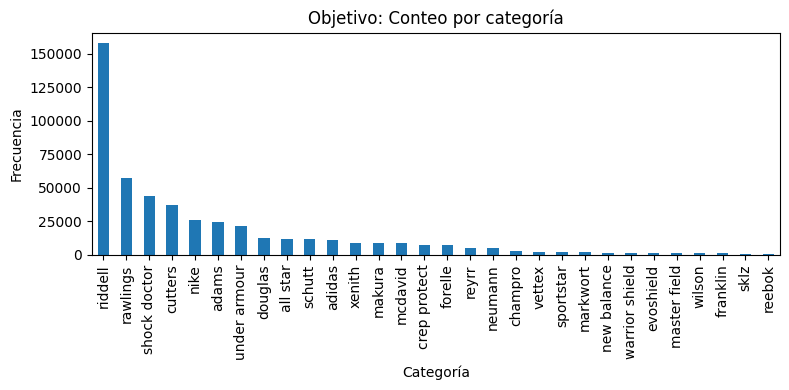

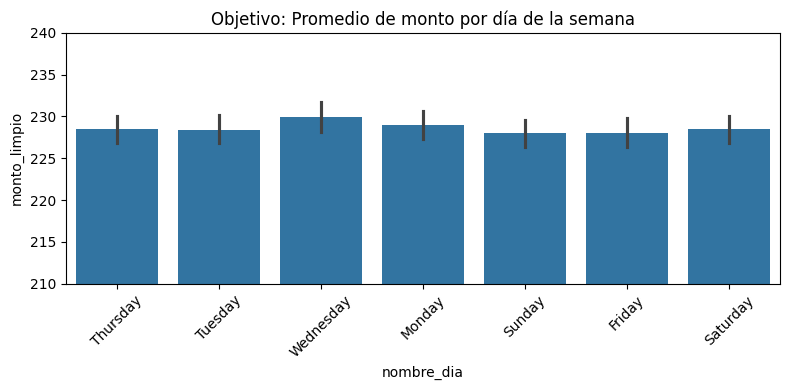

nombre_dia
Friday       228.029076
Monday       228.938253
Saturday     228.462411
Sunday       228.048370
Thursday     228.510089
Tuesday      228.430464
Wednesday    229.914786
Name: monto_limpio, dtype: float64


In [0]:
# Importa las librerías de visualización
import matplotlib.pyplot as plt  # Para gráficos estáticos como barras y líneas
import seaborn as sns           # Para gráficos estadísticos y visualizaciones avanzadas
import plotly.express as px     # Para gráficos interactivos

# Convierte el DataFrame de Spark a Pandas para facilitar la visualización
pdf = df_limpio.select(
    "categoria_limpia", "monto_limpio", "anio", "mes", "nombre_dia"
).toPandas()

# Gráfico de barras: muestra el conteo de registros por categoría limpia
plt.figure(figsize=(8,4))
conteo = pdf["categoria_limpia"].value_counts()
conteo.plot(kind="bar")
plt.title("Objetivo: Conteo por categoría")  # Título del objetivo
plt.xlabel("Categoría")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# Gráfico de barras con Seaborn: muestra el promedio de monto por nombre de día
orden_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plt.figure(figsize=(8,4))

sns.barplot(
    data=pdf, 
    x="nombre_dia", 
    y="monto_limpio", 
    estimator="mean")

plt.ylim(210, 240)   
plt.title("Objetivo: Promedio de monto por día de la semana")  # Título del objetivo
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Imprimimos los números exactos:
print(pdf.groupby("nombre_dia")["monto_limpio"].mean())






### Gráfica Interactiva 

In [0]:
import plotly.express as px

# 1. PASO OBLIGATORIO: Agrupar los datos (Crear el resumen)
# Esto convierte miles de filas en solo unas pocas para que la gráfica funcione
pdf_resumen = (
    pdf.groupby(["mes", "categoria_limpia"])["monto_limpio"]
    .mean()
    .reset_index()
    .sort_values("mes")
)

# 2. GRAFICAR EL RESUMEN
# Fíjate que aquí usamos 'pdf_resumen', NO 'pdf'
fig = px.bar(
    pdf_resumen,        # <--- ESTA ES LA CLAVE
    x="mes",
    y="monto_limpio",
    color="categoria_limpia",
    barmode="group",
    title="Objetivo: Monto promedio mensual por categoría"
)

display(fig)



![Gráfica Interactiva](Grafica.png)

### Análisis de Gráficas:
**1. Conteo por categoría:**
- La marca que más se vende es Ridell.
- La mayoría de las ventas se centran en pocas marcas(Rawlings-Under Armowr).
- Hay marcas que casi no se venden como Reebok.

**2. Promedio por Día:** 
- El comportamiento de compra es muy estable, el promedio varía entre 228 y 230.
- Solo el miércoles se vende un poco más.  

**3. Monto promedio mensual por categoría:**
- Durante todo el año los precios se mantienen casi iguales, no cambian mucho según la fecha.
- La gran diferencia está en la marca: algunas marcas premium, como Warrior Shield, tienen precios altos más de 500, mientras que otras más económicas, como Under Armour, cuestan menos de 100.
- En conclusión, el precio final depende más de la marca que escoge el cliente que del momento en el que compra.




